## IDS706 Data Engineering project

This project choose the recommended dataset of heart disease https://www.kaggle.com/datasets/navjotkaushal/heart-disease-uci-dataset

### Step1: Inspect the Data

 I need to read the CSV and import panda. In addition, I need to get a basic glimpse of the dataset.


In [1]:
# import panda
import pandas as pd

# read the csv file and get first few rows of the dataset

df = pd.read_csv("../data/cleanned-selected-columns.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4


In [2]:
# use info to check if there is any null entries and data types for each feature(column) of the data set
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    str    
 2   cp        918 non-null    str    
 3   trestbps  918 non-null    float64
 4   chol      918 non-null    float64
 5   fbs       918 non-null    bool   
 6   restecg   918 non-null    str    
 7   thalch    918 non-null    float64
 8   exang     918 non-null    bool   
 9   oldpeak   918 non-null    float64
dtypes: bool(2), float64(4), int64(1), str(3)
memory usage: 82.8 KB


In [3]:
# use describe to check some stats for this dataset
df.describe()

,age,trestbps,chol,thalch,oldpeak
count,918.000000,918.000000,918.000000,918.000000,918.00000
mean,53.510893,132.141612,199.862745,137.689542,0.85512
std,9.432617,17.924706,109.154522,25.153455,1.05845
min,28.000000,80.000000,0.000000,60.000000,-2.60000
25%,47.000000,120.000000,177.250000,120.000000,0.00000
50%,54.000000,130.000000,223.000000,140.000000,0.50000
75%,60.000000,140.000000,267.000000,155.750000,1.50000
max,77.000000,200.000000,603.000000,202.000000,6.20000


In [4]:
# As we have checked before using info, I wanna know if there is any null entry, I will check again.
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
dtype: int64

In [5]:
# as I checked above,there is no null value! now I wanna chekc if there is any completely duplicated rows in this dataset.
df.duplicated().sum()

np.int64(0)

### Step2: Basic Filtering and Grouping
After checking the information of the dataset, we can see that there is no null values and duplicate line. On the other hand we can see the range of age from 28 to 77. Age has alaways been a important factor in heart diesease topics.

In [6]:
# as mentioned above, I also find out that the median of the age in this dataset is 54. This seems a areasonable age to filter and regroup the dataset.
older_patients = df[df["age"] >= 54]
older_patients.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6
5,56,Male,typical angina,120.0,236.0,False,normal,178.0,False,0.8
6,62,Female,asymptomatic,140.0,268.0,False,lv hypertrophy,160.0,False,3.6


In [7]:
# simialrly, I will do subsetting for youger group
younger_patients = df[df["age"] < 54]
younger_patients.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5
4,41,Female,typical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4
9,53,Male,asymptomatic,140.0,203.0,True,lv hypertrophy,155.0,True,3.1
13,44,Male,typical angina,120.0,263.0,False,normal,173.0,False,0.0
14,52,Male,non-anginal,172.0,199.0,True,normal,162.0,False,0.5


In [8]:
# now I will use these two age subsets to group with chest pain variable
older_cp = older_patients.groupby("cp").size()
print(older_cp)

cp
asymptomatic      298
non-anginal       101
typical angina     99
dtype: int64


In [9]:
younger_cp = younger_patients.groupby("cp").size()
print(younger_cp)

cp
asymptomatic      198
non-anginal       102
typical angina    120
dtype: int64


Now we can see that the difference of chest pain in different age group, then we can also caculate the mean of serum cholesterol levels in different age group.

In [10]:
younger_patients["chol"].mean()

np.float64(207.0047619047619)

In [11]:
older_patients["chol"].mean()

np.float64(193.8393574297189)

### Step3：Explore a Machine Learning Algorithm
I explored a Linear Regression model to predict maximum heart rate (thalch) using age, resting blood pressure, cholesterol, and ST depression as input features.

In [12]:
# import machine learning packaages
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# set variables for input and output for machine learning
X = df[["age", "trestbps", "chol", "oldpeak"]]
y = df["thalch"]

# split the dataset into train sets and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# choose the model
model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mse = mean_squared_error(y_test, predictions)

print("Predictions:", predictions[:5])
print("Mean Squared Error:", mse)

Predictions: [119.80591631 123.81903982 148.07211324 143.34673759 125.54110091]
Mean Squared Error: 566.3627749534484


### Step4: Visualization
Now I will try to visualize the relationship between age groups and serum cholesterol levels since we only had tables from previous coding.

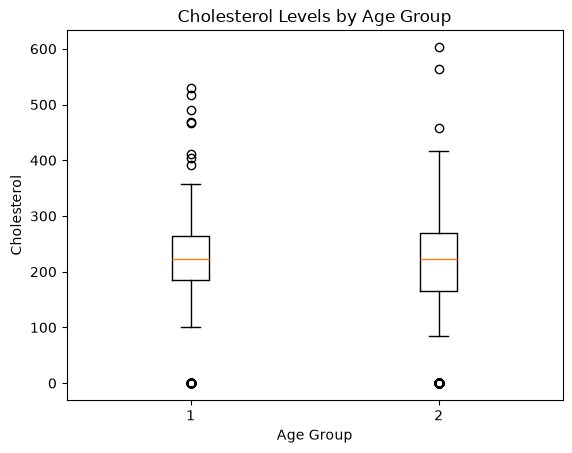

In [ ]:
# import the packages
import matplotlib.pyplot as plt

# draw the boxlot to compare two age groups
plt.boxplot(
    [younger_patients["chol"], older_patients["chol"]], label=["Younger", "Older"]
)

plt.title("Cholesterol Levels by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Cholesterol")
plt.show()

We can also try barplot for the mean for these two age groups which is more straightforward.

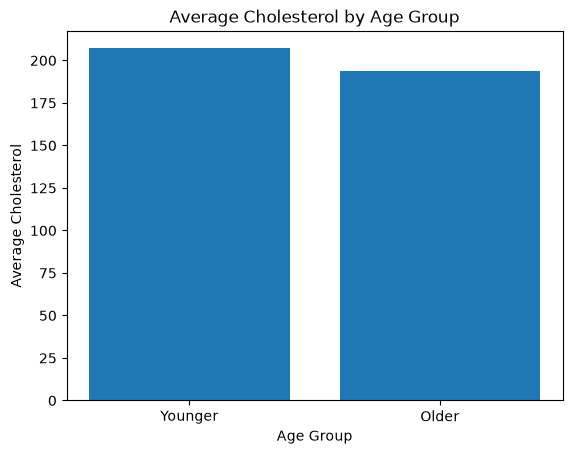

In [ ]:
mean_chol = [younger_patients["chol"].mean(), older_patients["chol"].mean()]

plt.bar(["Younger", "Older"], mean_chol)

plt.title("Average Cholesterol by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Cholesterol")
plt.show()

I also visualized the age groups and CP variable as mentioned before

In [ ]:
# first combine the previous two groupby subsets together
cp_counts = pd.DataFrame({"Younger": younger_cp, "Older": older_cp})

cp_counts

,Younger,Older
cp,,
asymptomatic,198,298
non-anginal,102,101
typical angina,120,99


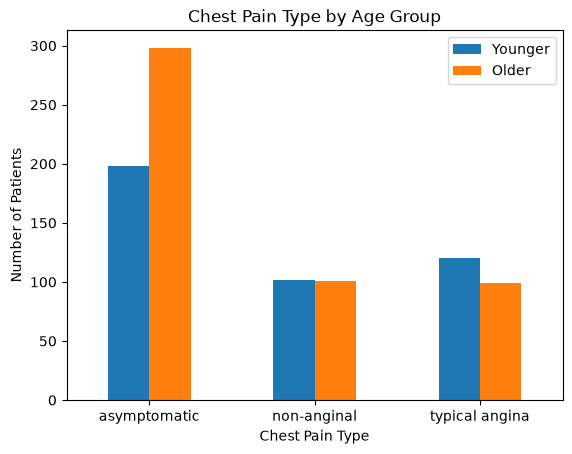

In [16]:
# bar plot seems more reasonable here because the CP variable is categorical
cp_counts.plot(kind="bar")

plt.title("Chest Pain Type by Age Group")
plt.xlabel("Chest Pain Type")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.show()

### Summary
The dataset contains 918 observations with no missing values or duplicate rows. Using the median age of 54, patients were divided into younger and older groups. Older patients had more asymptomatic chest pain cases, while average cholesterol was slightly higher among younger patients. A Linear Regression model was also explored to predict maximum heart rate using age, resting blood pressure, cholesterol, and ST depression. Several visualizations were created to compare cholesterol levels and chest pain patterns across age groups.

## Polars

In [ ]:
# import polars
import polars as pl

# read the data again using polars
df_pl = pl.read_csv("../data/cleanned-selected-columns.csv")

# show the data using polars
df_pl.head()

age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak
i64,str,str,f64,f64,bool,str,f64,bool,f64
63,"""Male""","""typical angina""",145.0,233.0,true,"""lv hypertrophy""",150.0,false,2.3
67,"""Male""","""asymptomatic""",160.0,286.0,false,"""lv hypertrophy""",108.0,true,1.5
67,"""Male""","""asymptomatic""",120.0,229.0,false,"""lv hypertrophy""",129.0,true,2.6
37,"""Male""","""non-anginal""",130.0,250.0,false,"""normal""",187.0,false,3.5
41,"""Female""","""typical angina""",130.0,204.0,false,"""lv hypertrophy""",172.0,false,1.4


The runtime in this notebook using polars is faster than panda when reading file.

In [18]:
older_pl = df_pl.filter(pl.col("age") >= 54)
older_pl.head()

age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak
i64,str,str,f64,f64,bool,str,f64,bool,f64
63,"""Male""","""typical angina""",145.0,233.0,true,"""lv hypertrophy""",150.0,false,2.3
67,"""Male""","""asymptomatic""",160.0,286.0,false,"""lv hypertrophy""",108.0,true,1.5
67,"""Male""","""asymptomatic""",120.0,229.0,false,"""lv hypertrophy""",129.0,true,2.6
56,"""Male""","""typical angina""",120.0,236.0,false,"""normal""",178.0,false,0.8
62,"""Female""","""asymptomatic""",140.0,268.0,false,"""lv hypertrophy""",160.0,false,3.6


In [ ]:
pl_group = df_pl.group_by("cp").agg(pl.col("chol").mean())
print(pl_group)

shape: (3, 2)
┌────────────────┬────────────┐
│ cp             ┆ chol       │
│ ---            ┆ ---        │
│ str            ┆ f64        │
╞════════════════╪════════════╡
│ non-anginal    ┆ 198.463054 │
│ asymptomatic   ┆ 188.106855 │
│ typical angina ┆ 227.785388 │
└────────────────┴────────────┘


In [20]:
pd_group = df.groupby("cp")["chol"].mean()
print(pd_group)

cp
asymptomatic      188.106855
non-anginal       198.463054
typical angina    227.785388
Name: chol, dtype: float64


The Pandas and Polars filtering/grouping results were equivalent, but Polars displayed the result in a more structured tabular format.